# Charcoal KBr FTIR EC Discrepancy Workflow

This is the project-facing companion to `charcoal_kbr_ftir_reference_analysis.ipynb`.

Use this notebook to test the actual FTIR-EC discrepancy workflow:
- subtract a KBr blank from lab pellet spectra,
- integrate functional-group regions,
- compare lab charcoal spectra with literature and ambient Adama spectra,
- prototype biomass/charcoal flags,
- simulate how added or recalibrated EC shifts Addis HIPS-vs-FTIR behavior.

The reference-library notebook answers: "what does charcoal look like?"  
This notebook answers: "how do we use that to diagnose or correct EC?"

## Setup

All downloaded raw spectra stay in `research/charcoal_ftir/data/raw/`, which is git-ignored. Lab spectra and digitized literature spectra should go under `data/interim/`, also git-ignored.

In [1]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=UserWarning)


def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'AGENTS.md').exists() and (candidate / 'research').exists():
            return candidate
    raise FileNotFoundError('Could not find repo root. Run from inside aethmodular.')

REPO_ROOT = find_repo_root()
PROJECT_DIR = REPO_ROOT / 'research' / 'charcoal_ftir'
RAW_DIR = PROJECT_DIR / 'data' / 'raw'
INTERIM_DIR = PROJECT_DIR / 'data' / 'interim'
LAB_KBR_DIR = INTERIM_DIR / 'lab_kbr_spectra'
LITERATURE_DIR = INTERIM_DIR / 'literature_spectra'
OUTPUT_DIR = PROJECT_DIR / 'output'
PLOT_DIR = OUTPUT_DIR / 'ec_discrepancy_plots'
ADAMA_DIR = REPO_ROOT / 'research' / 'spartan_ec_2026_06_16' / 'data' / 'adama'
SPARTAN_TABLE_DIR = REPO_ROOT / 'research' / 'spartan_ec_2026_06_16' / 'tables'

for directory in [LAB_KBR_DIR, LITERATURE_DIR, PLOT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (10, 5.8),
    'figure.dpi': 120,
    'savefig.dpi': 220,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.22,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

FEATURE_REGIONS = [
    {'feature': 'O-H / moisture', 'low': 3200, 'high': 3600, 'color': '#4C78A8'},
    {'feature': 'Aliphatic C-H', 'low': 2800, 'high': 3000, 'color': '#F58518'},
    {'feature': 'C=O / aromatic shoulder', 'low': 1650, 'high': 1750, 'color': '#E45756'},
    {'feature': 'Aromatic C=C', 'low': 1500, 'high': 1650, 'color': '#72B7B2'},
    {'feature': 'C-O / mineral overlap', 'low': 1000, 'high': 1300, 'color': '#54A24B'},
]

print(f'Repo root: {REPO_ROOT}')
print(f'Charcoal project: {PROJECT_DIR}')
print(f'Lab KBr spectra drop folder: {LAB_KBR_DIR}')
print(f'Literature spectra drop folder: {LITERATURE_DIR}')
print(f'Plot output folder: {PLOT_DIR}')

Repo root: /Users/ahmadjalil/github/aethmodular
Charcoal project: /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir
Lab KBr spectra drop folder: /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/data/interim/lab_kbr_spectra
Literature spectra drop folder: /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/data/interim/literature_spectra
Plot output folder: /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/output/ec_discrepancy_plots


## Core Spectral Helpers

These helpers handle common CSV shapes:
- normal two-column spectra: first numeric column is wavenumber, second is signal,
- JASCO-style CSV: metadata followed by `XYDATA`,
- wide spectra: one row per sample, wavenumber columns across the table.

In [2]:
WN_RE = re.compile(r'^[+-]?\d+(\.\d+)?$')


def numeric_wavenumber_from_col(col):
    text = str(col).strip()
    text = re.sub(r'\.\d+$', '', text)
    if not WN_RE.match(text):
        return None
    value = float(text)
    if 100 <= value <= 5000:
        return value
    return None


def normalize_vector(y):
    y = np.asarray(y, dtype=float)
    ymin = np.nanmin(y)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax - ymin) or ymax == ymin:
        return y * np.nan
    return (y - ymin) / (ymax - ymin)


def normalize_matrix(y):
    arr = np.asarray(y, dtype=float)
    lo = np.nanmin(arr, axis=1, keepdims=True)
    hi = np.nanmax(arr, axis=1, keepdims=True)
    denom = np.where((hi - lo) == 0, 1, hi - lo)
    return (arr - lo) / denom


def read_jasco_xy_csv(path):
    lines = Path(path).read_text(errors='replace').splitlines()
    try:
        start = next(i for i, line in enumerate(lines) if line.strip().upper() == 'XYDATA') + 1
    except StopIteration as exc:
        raise ValueError(f'No XYDATA block found in {path}') from exc
    data = []
    for line in lines[start:]:
        if ',' not in line:
            continue
        left, right = line.split(',', 1)
        try:
            data.append((float(left.strip()), float(right.strip())))
        except ValueError:
            continue
    return pd.DataFrame(data, columns=['wavenumber', 'signal'])


def read_two_column_spectrum(path):
    df = pd.read_csv(path)
    numeric = df.select_dtypes(include='number')
    if numeric.shape[1] < 2:
        raise ValueError(f'{path} needs at least two numeric columns.')
    out = numeric.iloc[:, :2].copy()
    out.columns = ['wavenumber', 'signal']
    return out.dropna()


def read_any_xy_spectrum(path):
    path = Path(path)
    text_head = path.read_text(errors='replace')[:1500]
    if 'XYDATA' in text_head.upper():
        return read_jasco_xy_csv(path)
    return read_two_column_spectrum(path)


def load_wide_spectra_csv(path):
    df = pd.read_csv(path)
    wn_cols = [c for c in df.columns if numeric_wavenumber_from_col(c) is not None]
    meta_cols = [c for c in df.columns if c not in wn_cols]
    wn = np.array([numeric_wavenumber_from_col(c) for c in wn_cols], dtype=float)
    y = df[wn_cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=float)
    order = np.argsort(wn)
    return df[meta_cols].copy(), wn[order], y[:, order]


def to_absorption_proxy(df, signal_col='signal', mode='auto'):
    out = df[['wavenumber', signal_col]].dropna().copy()
    y = out[signal_col].to_numpy(dtype=float)
    if mode == 'transmittance' or (mode == 'auto' and np.nanmedian(y) > 2):
        y = 100 - y
    out['response'] = y
    out['response_norm'] = normalize_vector(y)
    return out[['wavenumber', 'response', 'response_norm']]


def interpolate_response(df, target_wn, value_col='response_norm'):
    d = df[['wavenumber', value_col]].dropna().sort_values('wavenumber')
    return np.interp(target_wn, d['wavenumber'].to_numpy(), d[value_col].to_numpy())


def integrate_region(wn, y, low, high):
    wn = np.asarray(wn, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = (wn >= low) & (wn <= high)
    if mask.sum() < 2:
        return np.nan
    order = np.argsort(wn[mask])
    return float(np.trapz(y[mask][order], wn[mask][order]))


def feature_table_from_matrix(sample_names, wn, y_norm):
    rows = []
    for name, y in zip(sample_names, y_norm):
        for region in FEATURE_REGIONS:
            rows.append({
                'sample': name,
                'feature': region['feature'],
                'low_cm-1': region['low'],
                'high_cm-1': region['high'],
                'integrated_area': integrate_region(wn, y, region['low'], region['high']),
                'mean_intensity': float(np.nanmean(y[(wn >= region['low']) & (wn <= region['high'])])),
            })
    return pd.DataFrame(rows)


def shade_feature_regions(ax, ymax=1.0):
    for region in FEATURE_REGIONS:
        ax.axvspan(region['low'], region['high'], color=region['color'], alpha=0.10, lw=0)
        ax.text((region['low'] + region['high']) / 2, ymax, region['feature'],
                rotation=90, ha='center', va='top', fontsize=8, color=region['color'])


def savefig(name):
    path = PLOT_DIR / name
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved {path}')
    return path


def cosine_similarity(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 3:
        return np.nan
    aa = a[ok] - np.nanmean(a[ok])
    bb = b[ok] - np.nanmean(b[ok])
    denom = np.linalg.norm(aa) * np.linalg.norm(bb)
    return float(np.dot(aa, bb) / denom) if denom else np.nan

## 1. KBr Blank Subtraction Module

Drop lab spectra into `data/interim/lab_kbr_spectra/`.

Suggested filenames:
- `kbr_blank.csv`
- `costco_lump.csv`
- `generic_binchotan.csv`
- `kishu_hanmaru.csv`

The CSV can be a two-column export or a JASCO-style file with an `XYDATA` block. If a blank exists, it is interpolated to each sample grid and subtracted before normalization.

In [3]:
blank_path = LAB_KBR_DIR / 'kbr_blank.csv'
lab_paths = sorted(p for p in LAB_KBR_DIR.glob('*.csv') if p.name != 'kbr_blank.csv')

if not blank_path.exists() or not lab_paths:
    expected = pd.DataFrame({
        'file': ['kbr_blank.csv', 'costco_lump.csv', 'generic_binchotan.csv', 'kishu_hanmaru.csv'],
        'status': [
            'required for subtraction',
            'optional lab charcoal sample',
            'optional lab charcoal sample',
            'optional lab charcoal sample',
        ],
        'format': ['wavenumber, signal or JASCO XYDATA'] * 4,
    })
    print('No complete lab KBr set found yet. Add files here:')
    print(LAB_KBR_DIR)
    display(expected)
    lab_processed = {}
else:
    blank = to_absorption_proxy(read_any_xy_spectrum(blank_path))
    lab_processed = {}
    fig, axes = plt.subplots(len(lab_paths), 1, figsize=(11, 3.2 * len(lab_paths)), squeeze=False)
    for ax, path in zip(axes.ravel(), lab_paths):
        raw = to_absorption_proxy(read_any_xy_spectrum(path))
        blank_on_sample = interpolate_response(blank, raw['wavenumber'].to_numpy(), 'response_norm')
        corrected = raw.copy()
        corrected['blank_response_norm'] = blank_on_sample
        corrected['corrected_norm'] = normalize_vector(corrected['response_norm'].to_numpy() - blank_on_sample)
        lab_processed[path.stem] = corrected
        ax.plot(raw['wavenumber'], raw['response_norm'], lw=1.0, color='0.65', label='raw normalized')
        ax.plot(corrected['wavenumber'], corrected['corrected_norm'], lw=1.8, label='blank-subtracted')
        shade_feature_regions(ax, ymax=1.04)
        ax.invert_xaxis()
        ax.set_title(path.stem)
        ax.set_ylabel('normalized response')
        ax.legend(frameon=False)
    axes.ravel()[-1].set_xlabel('Wavenumber (cm^-1)')
    plt.tight_layout()
    savefig('lab_kbr_blank_subtraction.png')
    plt.show()

No complete lab KBr set found yet. Add files here:
/Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/data/interim/lab_kbr_spectra


,file,status,format
0,kbr_blank.csv,required for subtraction,"wavenumber, signal or JASCO XYDATA"
1,costco_lump.csv,optional lab charcoal sample,"wavenumber, signal or JASCO XYDATA"
2,generic_binchotan.csv,optional lab charcoal sample,"wavenumber, signal or JASCO XYDATA"
3,kishu_hanmaru.csv,optional lab charcoal sample,"wavenumber, signal or JASCO XYDATA"


## 2. Functional-Group Quantification and OC/EC Calculator

This section integrates each diagnostic FTIR region. If lab spectra have been dropped in, it analyzes those. Otherwise it demonstrates the same feature extraction on the Minatre/Dryad temperature reference spectra.

For OC/EC ratios, optionally add `data/interim/lab_carbon_results.csv` with columns:
`sample, OC_ug_m3, EC_ug_m3`.

No lab spectra yet; feature table shown for Minatre temperature means.


/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_6615/3621810262.py:100: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y[mask][order], wn[mask][order]))


,sample,feature,low_cm-1,high_cm-1,integrated_area,mean_intensity
0,Minatre mean 200 C,O-H / moisture,3200,3600,121.8376,0.4052
1,Minatre mean 200 C,Aliphatic C-H,2800,3000,83.2914,0.4158
2,Minatre mean 200 C,C=O / aromatic shoulder,1650,1750,69.8692,0.6993
3,Minatre mean 200 C,Aromatic C=C,1500,1650,79.6247,0.5309
4,Minatre mean 200 C,C-O / mineral overlap,1000,1300,122.1147,0.4071
5,Minatre mean 300 C,O-H / moisture,3200,3600,156.7338,0.5211
6,Minatre mean 300 C,Aliphatic C-H,2800,3000,81.5941,0.4073
7,Minatre mean 300 C,C=O / aromatic shoulder,1650,1750,70.0830,0.7001
8,Minatre mean 300 C,Aromatic C=C,1500,1650,82.8747,0.5522
9,Minatre mean 300 C,C-O / mineral overlap,1000,1300,140.5084,0.4681


Saved /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/output/ec_discrepancy_plots/functional_group_region_intensity_heatmap.png


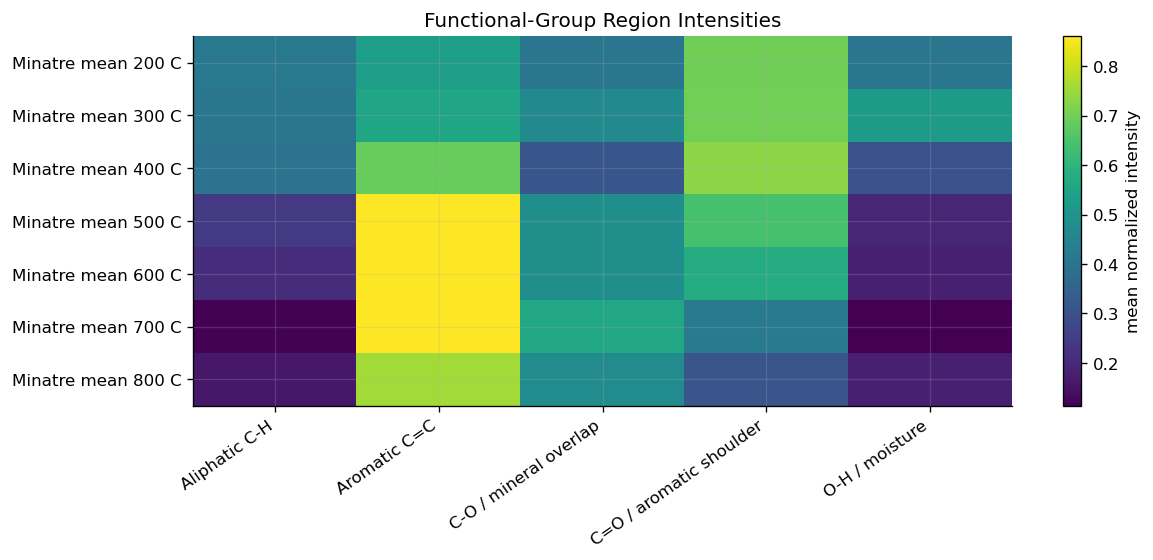

In [4]:
feature_tables = []

if 'lab_processed' in globals() and lab_processed:
    for sample, df in lab_processed.items():
        wn = df['wavenumber'].to_numpy(dtype=float)
        y = df['corrected_norm'].to_numpy(dtype=float)
        feature_tables.append(feature_table_from_matrix([sample], wn, y.reshape(1, -1)))
    feature_summary = pd.concat(feature_tables, ignore_index=True)
    print('Feature table from blank-subtracted lab spectra.')
else:
    minatre_path = RAW_DIR / 'minatre_dryad_charcoal_temperature' / 'Minatre_reference_spectra.csv'
    minatre_meta, minatre_wn, minatre_y = load_wide_spectra_csv(minatre_path)
    minatre_meta = minatre_meta.rename(columns={'Species': 'species', 'Temperature': 'temperature'})
    minatre_norm = normalize_matrix(minatre_y)
    # Average by charring temperature for a compact demonstration table.
    rows = []
    for temp in sorted(minatre_meta['temperature'].dropna().unique()):
        mask = minatre_meta['temperature'].to_numpy() == temp
        rows.append((f'Minatre mean {int(temp)} C', np.nanmean(minatre_norm[mask], axis=0)))
    feature_summary = feature_table_from_matrix([r[0] for r in rows], minatre_wn, np.vstack([r[1] for r in rows]))
    print('No lab spectra yet; feature table shown for Minatre temperature means.')

display(feature_summary.head(20).round(4))

feature_pivot = feature_summary.pivot_table(index='sample', columns='feature', values='mean_intensity')
fig, ax = plt.subplots(figsize=(11, max(4, 0.38 * len(feature_pivot))))
im = ax.imshow(feature_pivot.to_numpy(), aspect='auto', cmap='viridis')
ax.set_xticks(range(feature_pivot.shape[1]))
ax.set_xticklabels(feature_pivot.columns, rotation=35, ha='right')
ax.set_yticks(range(feature_pivot.shape[0]))
ax.set_yticklabels(feature_pivot.index)
ax.set_title('Functional-Group Region Intensities')
plt.colorbar(im, ax=ax, label='mean normalized intensity')
savefig('functional_group_region_intensity_heatmap.png')
plt.show()

In [5]:
carbon_path = INTERIM_DIR / 'lab_carbon_results.csv'
if carbon_path.exists():
    carbon = pd.read_csv(carbon_path)
    carbon['OC_EC_ratio'] = carbon['OC_ug_m3'] / carbon['EC_ug_m3']
    carbon['EC_fraction'] = carbon['EC_ug_m3'] / (carbon['OC_ug_m3'] + carbon['EC_ug_m3'])
    print('Loaded lab OC/EC results:')
    display(carbon.round(3))
else:
    template = pd.DataFrame({
        'sample': ['costco_lump', 'generic_binchotan', 'kishu_hanmaru'],
        'OC_ug_m3': [np.nan, np.nan, np.nan],
        'EC_ug_m3': [np.nan, np.nan, np.nan],
    })
    print('No lab carbon result table found yet. Optional template:')
    print(carbon_path)
    display(template)

No lab carbon result table found yet. Optional template:
/Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/data/interim/lab_carbon_results.csv


,sample,OC_ug_m3,EC_ug_m3
0,costco_lump,NaN,NaN
1,generic_binchotan,NaN,NaN
2,kishu_hanmaru,NaN,NaN


## 3. Literature Reference Spectra Overlay

Put digitized or downloaded literature spectra in `data/interim/literature_spectra/` as CSV files. Suggested names:
- `takahama_cold_start.csv`
- `takahama_unburned_fuel.csv`
- `emily_li_cookstove_charcoal_fig4.csv`

This keeps digitized figure data separate from downloaded raw datasets and makes the overlay reproducible.

In [6]:
lit_paths = sorted(LITERATURE_DIR.glob('*.csv'))
if not lit_paths:
    print('No literature spectra CSVs found yet. Add digitized CSVs here:')
    print(LITERATURE_DIR)
    display(pd.DataFrame({
        'target_file': ['takahama_cold_start.csv', 'takahama_unburned_fuel.csv', 'emily_li_cookstove_charcoal_fig4.csv'],
        'required_columns': ['wavenumber, signal'] * 3,
        'note': ['digitized from paper figure or author-provided data'] * 3,
    }))
else:
    fig, ax = plt.subplots(figsize=(12, 6))
    for path in lit_paths:
        df = to_absorption_proxy(read_any_xy_spectrum(path))
        ax.plot(df['wavenumber'], df['response_norm'], lw=1.6, label=path.stem)
    if 'lab_processed' in globals() and lab_processed:
        for sample, df in lab_processed.items():
            ax.plot(df['wavenumber'], df['corrected_norm'], lw=2.2, ls='--', label=f'lab: {sample}')
    shade_feature_regions(ax, ymax=1.04)
    ax.invert_xaxis()
    ax.set_title('Literature vs Lab Charcoal Spectra')
    ax.set_xlabel('Wavenumber (cm^-1)')
    ax.set_ylabel('Normalized response')
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
    savefig('literature_lab_overlay.png')
    plt.show()

No literature spectra CSVs found yet. Add digitized CSVs here:
/Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/data/interim/literature_spectra


,target_file,required_columns,note
0,takahama_cold_start.csv,"wavenumber, signal",digitized from paper figure or author-provided...
1,takahama_unburned_fuel.csv,"wavenumber, signal",digitized from paper figure or author-provided...
2,emily_li_cookstove_charcoal_fig4.csv,"wavenumber, signal",digitized from paper figure or author-provided...


## 4. Real-World Ground Truth: Adama Sample Comparison

This section uses the existing Batch54 Adama files when present:
- PTFE FTIR spectra and FTIR EC/OC predictions,
- quartz TOR/OCEC data,
- prior Adama EC calibration comparison outputs.

The comparison is intentionally cautious because PTFE FTIR spectra, KBr pellet spectra, ATR spectra, and digitized paper spectra are not interchangeable without matched preprocessing.

Adama spectra available: True
Adama directory: /Users/ahmadjalil/github/aethmodular/research/spartan_ec_2026_06_16/data/adama


Saved /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/output/ec_discrepancy_plots/adama_ptfe_ftir_spectra.png


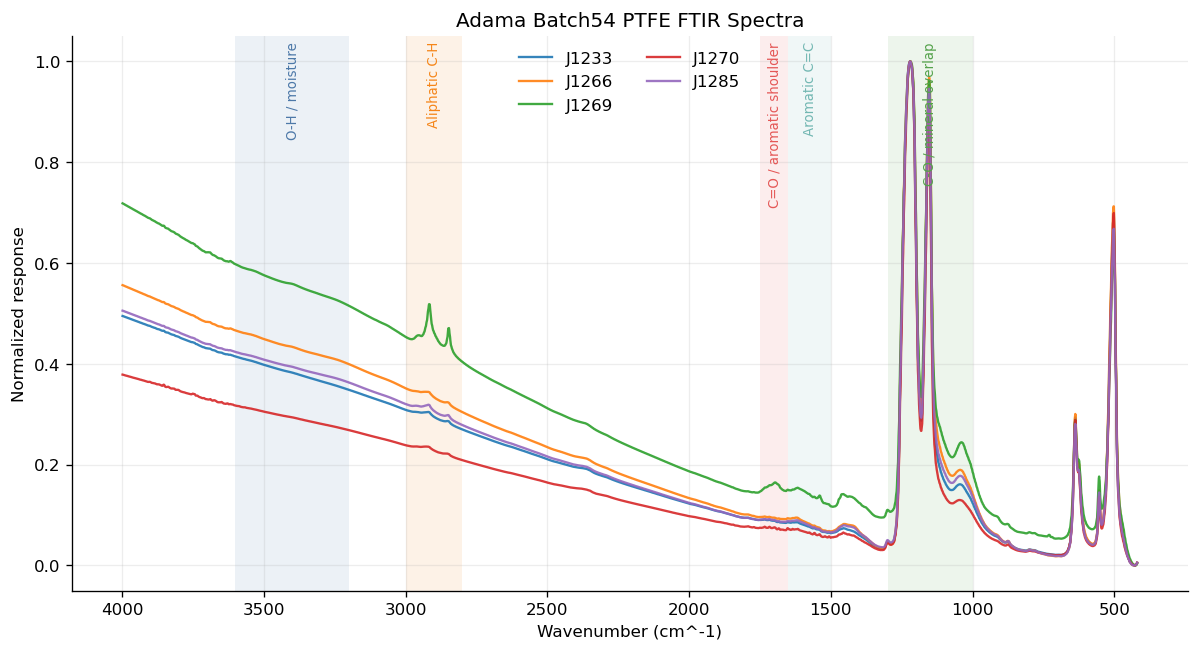

/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_6615/3621810262.py:100: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y[mask][order], wn[mask][order]))


feature,Aliphatic C-H,Aromatic C=C,C-O / mineral overlap,C=O / aromatic shoulder,O-H / moisture
sample,,,,,
J1233,0.2934,0.0761,0.3555,0.0879,0.3820
J1266,0.3322,0.0821,0.3790,0.0944,0.4332
J1269,0.4496,0.1397,0.4096,0.1552,0.5570
J1270,0.2271,0.0645,0.3323,0.0736,0.2933
J1285,0.3047,0.0786,0.3658,0.0894,0.3937


In [7]:
adama_spectra_path = ADAMA_DIR / 'adama_ptfe_spectra_batch54.csv'
adama_ftir_path = ADAMA_DIR / 'adama_ptfe_ftir_batch54.csv'
adama_tor_path = ADAMA_DIR / 'adama_quartz_tor_batch54.csv'
adama_cmp_path = SPARTAN_TABLE_DIR / 'adama_ec_calibration_comparison.csv'

have_adama = adama_spectra_path.exists() and adama_ftir_path.exists()
print('Adama spectra available:', have_adama)
print('Adama directory:', ADAMA_DIR)

if have_adama:
    adama_meta_raw, adama_wn, adama_y = load_wide_spectra_csv(adama_spectra_path)
    adama_norm = normalize_matrix(adama_y)
    adama_ftir = pd.read_csv(adama_ftir_path)
    adama_ec_meta = adama_ftir[adama_ftir['Parameter'].eq('EC_ftir')].reset_index(drop=True)
    sample_names = adama_ec_meta['FilterId'].astype(str).tolist()
    if len(sample_names) != adama_norm.shape[0]:
        sample_names = [str(x) for x in adama_meta_raw.iloc[:, 0].tolist()]

    fig, ax = plt.subplots(figsize=(12, 6))
    for name, y in zip(sample_names, adama_norm):
        ax.plot(adama_wn, y, lw=1.4, alpha=0.9, label=name)
    shade_feature_regions(ax, ymax=1.04)
    ax.invert_xaxis()
    ax.set_title('Adama Batch54 PTFE FTIR Spectra')
    ax.set_xlabel('Wavenumber (cm^-1)')
    ax.set_ylabel('Normalized response')
    ax.legend(frameon=False, ncol=2)
    savefig('adama_ptfe_ftir_spectra.png')
    plt.show()

    adama_features = feature_table_from_matrix(sample_names, adama_wn, adama_norm)
    display(adama_features.pivot_table(index='sample', columns='feature', values='mean_intensity').round(4))
else:
    print('Adama files not found. This section will activate when Batch54 files are present.')

,FilterId,date,EC_general,EC_biomass_tool,EC_biomass_local_sig,ratio_tool,ratio_local,ECTR,char_soot,OC_EC
0,J1233,2024-07-26,3.726,9.018,11.358,2.421,3.049,4.809,0.018,7.229
1,J1266,2024-07-20,4.413,4.381,9.925,0.993,2.249,6.250,0.065,5.927
2,J1269,2024-07-09,15.190,12.530,12.158,0.825,0.800,8.855,0.171,6.151
3,J1270,2024-07-30,2.051,10.955,9.742,5.340,4.749,7.745,0.580,4.629
4,J1285,2024-07-23,5.739,10.419,12.255,1.815,2.135,6.333,0.073,6.078


Saved /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/output/ec_discrepancy_plots/adama_tor_ground_truth_summary.png


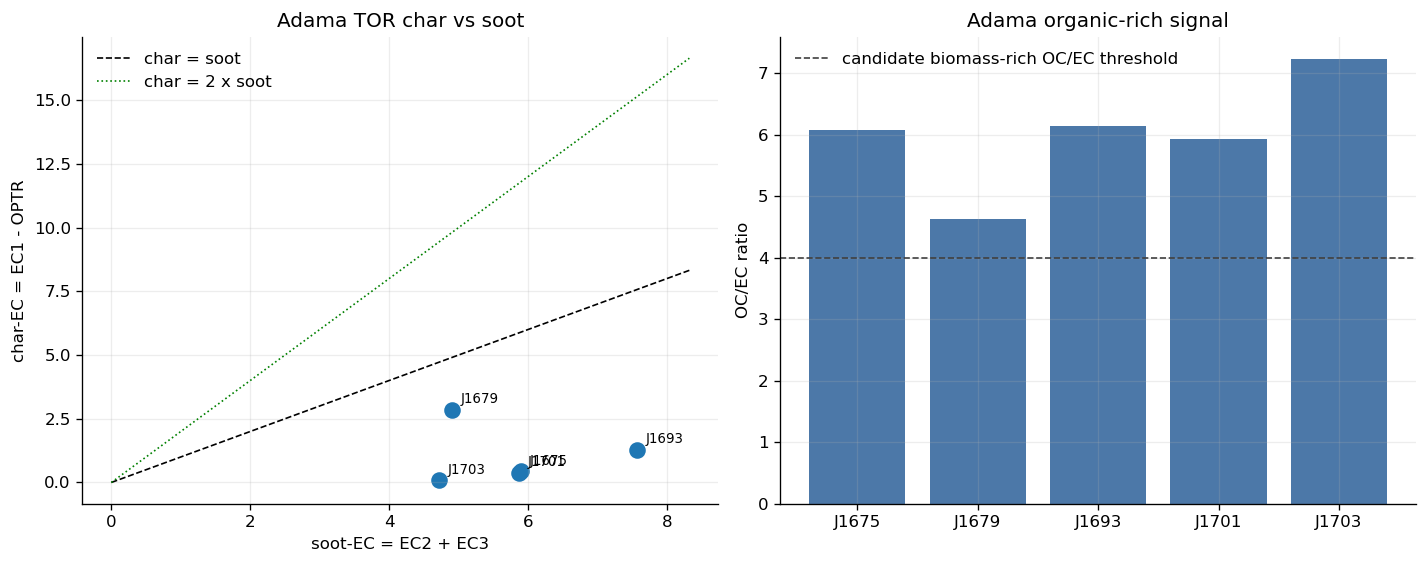

In [8]:
if have_adama and adama_tor_path.exists():
    tor = pd.read_csv(adama_tor_path)
    tor_wide = tor.pivot_table(index=['FilterId', 'SampleDate'], columns='Parameter', values='MassLoading_ug').reset_index()
    tor_wide['date'] = pd.to_datetime(tor_wide['SampleDate']).dt.normalize()
    tor_wide['char_EC'] = tor_wide['EC1'] - tor_wide['OPTR']
    tor_wide['soot_EC'] = tor_wide['EC2'] + tor_wide['EC3']
    tor_wide['char_soot_ratio'] = tor_wide['char_EC'] / tor_wide['soot_EC']
    tor_wide['OC_EC_ratio'] = tor_wide['OCTR'] / tor_wide['ECTR']

    if adama_cmp_path.exists():
        cmp = pd.read_csv(adama_cmp_path)
        display(cmp.round(3))
    else:
        display(tor_wide[['FilterId', 'date', 'ECTR', 'char_soot_ratio', 'OC_EC_ratio']].round(3))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    axes[0].scatter(tor_wide['soot_EC'], tor_wide['char_EC'], s=80)
    for _, r in tor_wide.iterrows():
        axes[0].annotate(r['FilterId'], (r['soot_EC'], r['char_EC']), xytext=(5, 4), textcoords='offset points', fontsize=8)
    lim = max(tor_wide['soot_EC'].max(), tor_wide['char_EC'].max()) * 1.1
    axes[0].plot([0, lim], [0, lim], 'k--', lw=1, label='char = soot')
    axes[0].plot([0, lim], [0, 2 * lim], color='green', ls=':', lw=1, label='char = 2 x soot')
    axes[0].set_xlabel('soot-EC = EC2 + EC3')
    axes[0].set_ylabel('char-EC = EC1 - OPTR')
    axes[0].set_title('Adama TOR char vs soot')
    axes[0].legend(frameon=False)

    axes[1].bar(tor_wide['FilterId'], tor_wide['OC_EC_ratio'], color='#4C78A8')
    axes[1].axhline(4, color='0.25', ls='--', lw=1, label='candidate biomass-rich OC/EC threshold')
    axes[1].set_ylabel('OC/EC ratio')
    axes[1].set_title('Adama organic-rich signal')
    axes[1].legend(frameon=False)
    plt.tight_layout()
    savefig('adama_tor_ground_truth_summary.png')
    plt.show()
elif have_adama:
    print('Adama spectra exist, but quartz TOR file is missing.')

## 5. Biomass-Burning Decision Tree / Classification Placeholder

This is a testing ground, not a final classifier. It exposes the threshold logic so the team can revise it after lab spectra and literature overlays are in place.

Current candidate logic:
- high `OC/EC` flags biomass-influenced aerosol,
- high `char/soot` flags char-rich thermal EC,
- spectral similarity can be added once lab KBr spectra are available.

Parameter,FilterId,date,char_soot_ratio,OC_EC_ratio,high_OC_EC,char_rich_EC,candidate_biomass_influenced,classification_note
0,J1675,2024-07-23,0.073,6.078,True,False,True,organic-rich but soot-leaning EC
1,J1679,2024-07-30,0.580,4.629,True,False,True,organic-rich but soot-leaning EC
2,J1693,2024-07-09,0.171,6.151,True,False,True,organic-rich but soot-leaning EC
3,J1701,2024-07-20,0.065,5.927,True,False,True,organic-rich but soot-leaning EC
4,J1703,2024-07-26,0.018,7.229,True,False,True,organic-rich but soot-leaning EC


Saved /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/output/ec_discrepancy_plots/prototype_biomass_decision_space.png


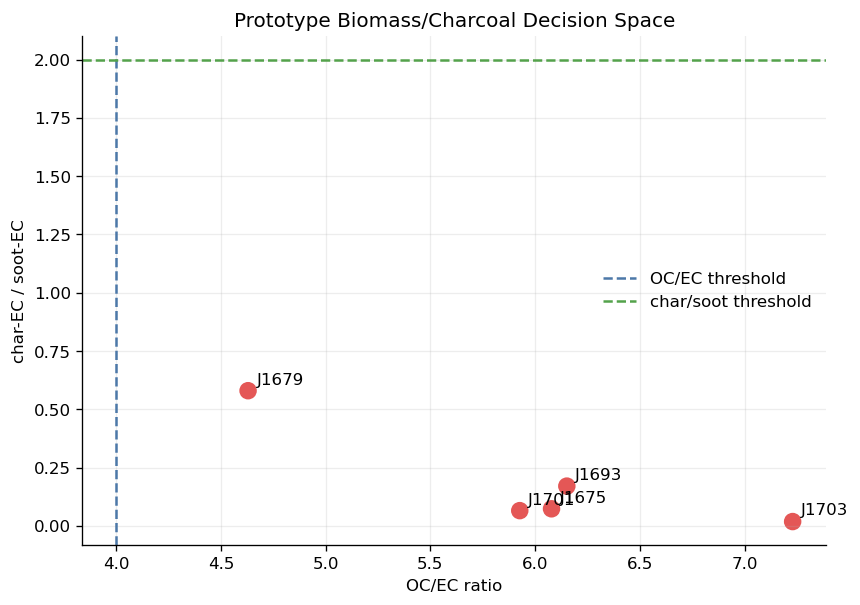

In [9]:
THRESHOLDS = {
    'OC_EC_biomass_min': 4.0,
    'char_soot_char_min': 2.0,
}

if have_adama and adama_tor_path.exists():
    decision = tor_wide[['FilterId', 'date', 'char_soot_ratio', 'OC_EC_ratio']].copy()
    decision['high_OC_EC'] = decision['OC_EC_ratio'] >= THRESHOLDS['OC_EC_biomass_min']
    decision['char_rich_EC'] = decision['char_soot_ratio'] >= THRESHOLDS['char_soot_char_min']
    decision['candidate_biomass_influenced'] = decision['high_OC_EC'] | decision['char_rich_EC']
    decision['classification_note'] = np.select(
        [decision['high_OC_EC'] & decision['char_rich_EC'], decision['high_OC_EC'], decision['char_rich_EC']],
        ['organic-rich and char-rich', 'organic-rich but soot-leaning EC', 'char-rich EC'],
        default='not flagged by current thresholds',
    )
    display(decision.round(3))

    fig, ax = plt.subplots(figsize=(8, 5.5))
    colors = decision['candidate_biomass_influenced'].map({True: '#E45756', False: '0.55'})
    ax.scatter(decision['OC_EC_ratio'], decision['char_soot_ratio'], c=colors, s=90)
    for _, r in decision.iterrows():
        ax.annotate(r['FilterId'], (r['OC_EC_ratio'], r['char_soot_ratio']), xytext=(5, 4), textcoords='offset points')
    ax.axvline(THRESHOLDS['OC_EC_biomass_min'], color='#4C78A8', ls='--', label='OC/EC threshold')
    ax.axhline(THRESHOLDS['char_soot_char_min'], color='#54A24B', ls='--', label='char/soot threshold')
    ax.set_xlabel('OC/EC ratio')
    ax.set_ylabel('char-EC / soot-EC')
    ax.set_title('Prototype Biomass/Charcoal Decision Space')
    ax.legend(frameon=False)
    savefig('prototype_biomass_decision_space.png')
    plt.show()
else:
    print('Decision tree demonstration needs Adama TOR or another table with OC/EC and char/soot.')

## 6. The 7 ug/m3 EC Shift Simulation

This section simulates the meeting calculation: what happens to HIPS-vs-FTIR agreement if Addis EC is shifted upward by a fixed amount, such as 7 ug/m3?

It uses `research/spartan_ec_2026_06_16/tables/biomass_vs_general_ec.csv` if present. That file contains Addis FTIR EC and HIPS BC-equivalent values from prior workflow work.

,EC_shift_ug_m3,n,slope,intercept,r2,median_HIPS_minus_shifted_EC,median_effective_MAC_m2_g
0,0,156,0.425,2.648,0.794,-0.277,9.412
1,3,156,0.425,1.372,0.794,-3.277,5.926
2,5,156,0.425,0.522,0.794,-5.277,4.729
3,7,156,0.425,-0.329,0.794,-7.277,4.019
4,10,156,0.425,-1.605,0.794,-10.277,3.196


Saved /Users/ahmadjalil/github/aethmodular/research/charcoal_ftir/output/ec_discrepancy_plots/seven_ug_ec_shift_simulation.png


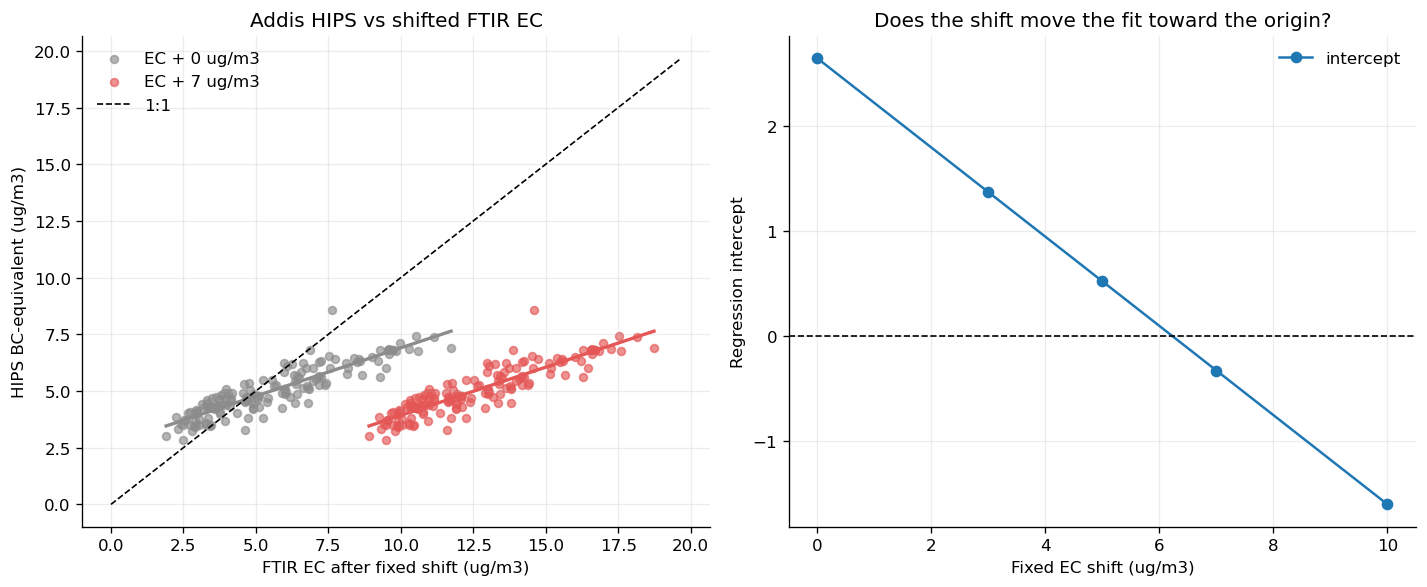

In [10]:
biomass_table_path = SPARTAN_TABLE_DIR / 'biomass_vs_general_ec.csv'

def fit_line(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3:
        return {'n': int(ok.sum()), 'slope': np.nan, 'intercept': np.nan, 'r2': np.nan}
    slope, intercept = np.polyfit(x[ok], y[ok], 1)
    pred = slope * x[ok] + intercept
    ss_res = np.sum((y[ok] - pred) ** 2)
    ss_tot = np.sum((y[ok] - np.mean(y[ok])) ** 2)
    return {'n': int(ok.sum()), 'slope': slope, 'intercept': intercept, 'r2': 1 - ss_res / ss_tot if ss_tot else np.nan}

if biomass_table_path.exists():
    biomass = pd.read_csv(biomass_table_path)
    shift_values = [0, 3, 5, 7, 10]
    sim_rows = []
    y = biomass['fabs_bc_ugm3']
    for shift in shift_values:
        x = biomass['EC_general'] + shift
        stats = fit_line(x, y)
        sim_rows.append({
            'EC_shift_ug_m3': shift,
            **stats,
            'median_HIPS_minus_shifted_EC': float(np.nanmedian(y - x)),
            'median_effective_MAC_m2_g': float(np.nanmedian(biomass['HIPS_Fabs'] / x)),
        })
    sim = pd.DataFrame(sim_rows)
    display(sim.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for shift, color in [(0, '0.55'), (7, '#E45756')]:
        x = biomass['EC_general'] + shift
        axes[0].scatter(x, y, s=22, alpha=0.65, label=f'EC + {shift} ug/m3', color=color)
        stats = fit_line(x, y)
        xx = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        axes[0].plot(xx, stats['slope'] * xx + stats['intercept'], color=color, lw=2)
    lim = max(np.nanmax(y), np.nanmax(biomass['EC_general'] + 7)) * 1.05
    axes[0].plot([0, lim], [0, lim], 'k--', lw=1, label='1:1')
    axes[0].set_xlabel('FTIR EC after fixed shift (ug/m3)')
    axes[0].set_ylabel('HIPS BC-equivalent (ug/m3)')
    axes[0].set_title('Addis HIPS vs shifted FTIR EC')
    axes[0].legend(frameon=False)

    axes[1].plot(sim['EC_shift_ug_m3'], sim['intercept'], marker='o', label='intercept')
    axes[1].axhline(0, color='k', lw=1, ls='--')
    axes[1].set_xlabel('Fixed EC shift (ug/m3)')
    axes[1].set_ylabel('Regression intercept')
    axes[1].set_title('Does the shift move the fit toward the origin?')
    axes[1].legend(frameon=False)
    plt.tight_layout()
    savefig('seven_ug_ec_shift_simulation.png')
    plt.show()
else:
    print('Missing biomass comparison table:')
    print(biomass_table_path)

## Next Steps

1. Add the lab KBr blank and charcoal pellet spectra to `data/interim/lab_kbr_spectra/`.
2. Add digitized Takahama and Emily Li spectra to `data/interim/literature_spectra/`.
3. Rerun this notebook to produce blank-subtracted overlays and feature tables.
4. Replace prototype thresholds with thresholds justified by lab spectra, Adama TOR data, and literature references.
5. Use the 7 ug/m3 simulation as a communication plot, not as the final correction model.